# Importar e explorar os dados


In [40]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

pd.set_option("display.max_columns", 200)

csv_path = "base_churns.csv"
if not os.path.exists(csv_path):
    files = [f for f in os.listdir(".") if f.lower().endswith(".csv")]
    files
df = pd.read_csv(csv_path)
df

,id_cliente,tempo_contrato_meses,plano,regiao,logins_mes,tickets_suporte,valor_mensal,inadimplencia,qtd_funcionarios,uso_media_diaria_horas,churn
0,C001,12,Básico,Sudeste,15,2,120,0,3,1.8,0
1,C002,3,Premium,Sul,4,6,350,1,8,0.5,1
2,C003,8,Intermediário,Sudeste,10,1,210,0,5,1.2,0
3,C004,24,Premium,Centro-Oeste,25,0,370,0,12,3.5,0
4,C005,6,Básico,Nordeste,6,4,130,1,2,0.9,1
...,...,...,...,...,...,...,...,...,...,...,...
95,C096,18,Intermediário,Sul,21,1,220,0,6,2.7,0
96,C097,7,Básico,Sudeste,8,3,120,1,2,1.1,1
97,C098,11,Premium,Centro-Oeste,23,0,355,0,11,3.1,0
98,C099,2,Básico,Sul,4,7,105,1,1,0.4,1


In [41]:
df.head()

,id_cliente,tempo_contrato_meses,plano,regiao,logins_mes,tickets_suporte,valor_mensal,inadimplencia,qtd_funcionarios,uso_media_diaria_horas,churn
0,C001,12,Básico,Sudeste,15,2,120,0,3,1.8,0
1,C002,3,Premium,Sul,4,6,350,1,8,0.5,1
2,C003,8,Intermediário,Sudeste,10,1,210,0,5,1.2,0
3,C004,24,Premium,Centro-Oeste,25,0,370,0,12,3.5,0
4,C005,6,Básico,Nordeste,6,4,130,1,2,0.9,1


In [42]:
df.shape

(100, 11)

In [43]:
df.dtypes

id_cliente                 object
tempo_contrato_meses        int64
plano                      object
regiao                     object
logins_mes                  int64
tickets_suporte             int64
valor_mensal                int64
inadimplencia               int64
qtd_funcionarios            int64
uso_media_diaria_horas    float64
churn                       int64
dtype: object

In [44]:
df.isna().sum().sort_values(ascending=False)

id_cliente                0
tempo_contrato_meses      0
plano                     0
regiao                    0
logins_mes                0
tickets_suporte           0
valor_mensal              0
inadimplencia             0
qtd_funcionarios          0
uso_media_diaria_horas    0
churn                     0
dtype: int64

In [45]:
df.describe()

,tempo_contrato_meses,logins_mes,tickets_suporte,valor_mensal,inadimplencia,qtd_funcionarios,uso_media_diaria_horas,churn
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,9.690000,13.120000,2.570000,204.800000,0.420000,5.340000,1.729000,0.420000
std,6.107943,7.413174,2.370931,97.125141,0.496045,3.736849,1.045461,0.496045
min,1.000000,2.000000,0.000000,100.000000,0.000000,1.000000,0.200000,0.000000
25%,5.000000,6.000000,1.000000,115.000000,0.000000,2.000000,0.800000,0.000000
50%,9.000000,12.500000,1.500000,205.000000,0.000000,5.000000,1.650000,0.000000
75%,13.000000,19.000000,5.000000,240.000000,1.000000,7.000000,2.700000,1.000000
max,30.000000,29.000000,8.000000,400.000000,1.000000,15.000000,4.000000,1.000000


# Visualizações


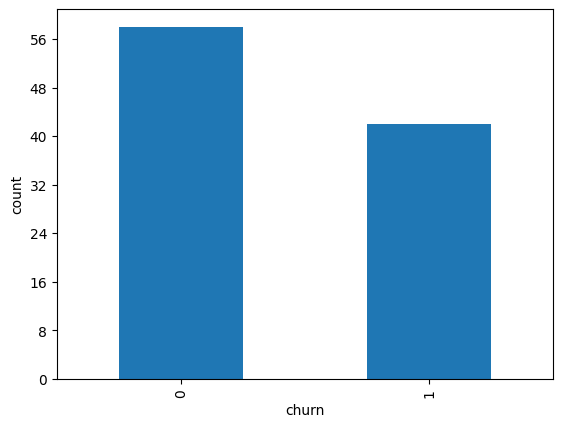

In [46]:
# Distribuição do churn
ax = df["churn"].value_counts().sort_index().plot(kind="bar")
ax.set_xlabel("churn")
ax.set_ylabel("count")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

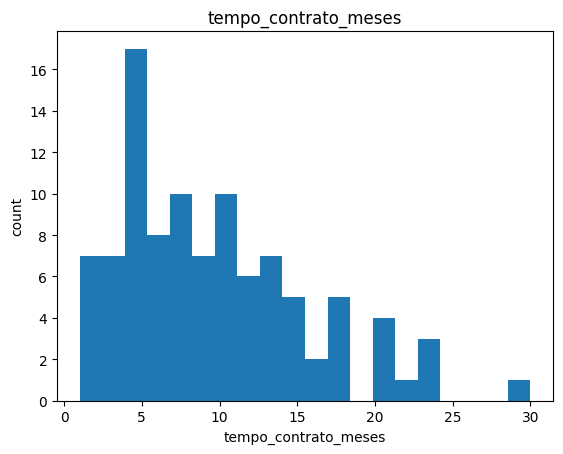

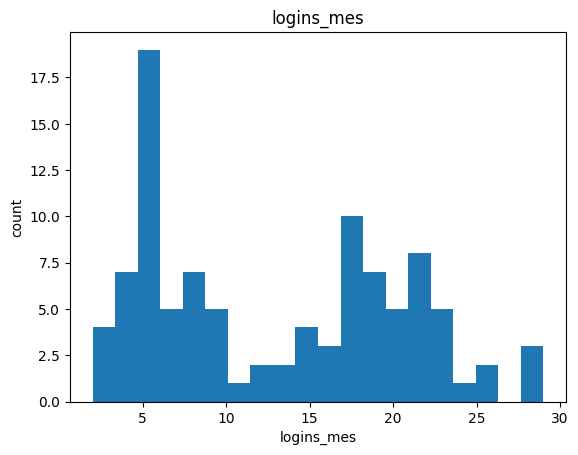

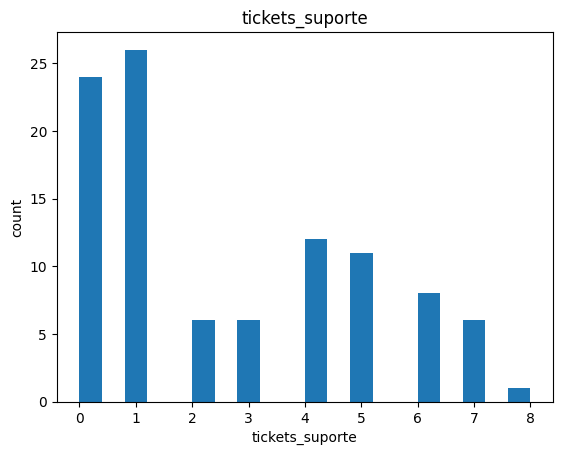

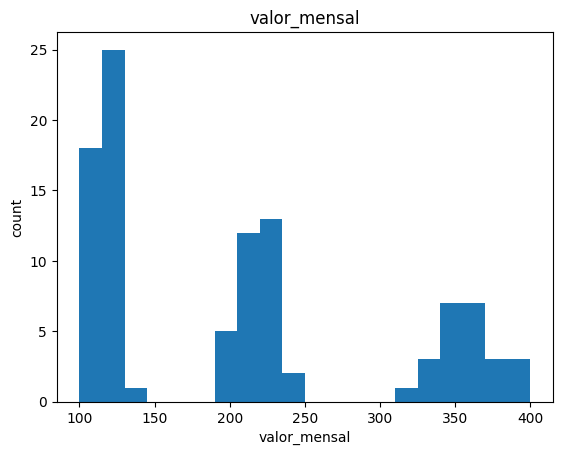

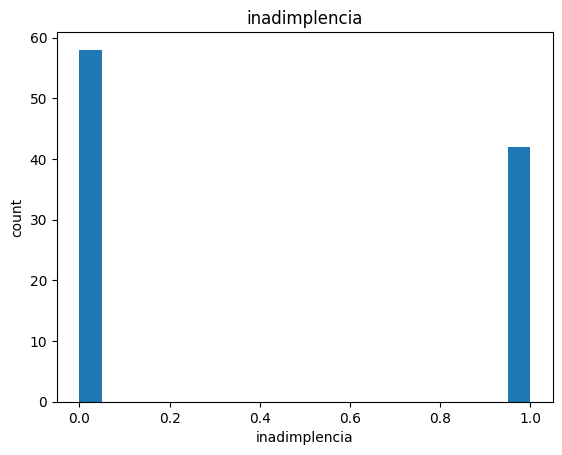

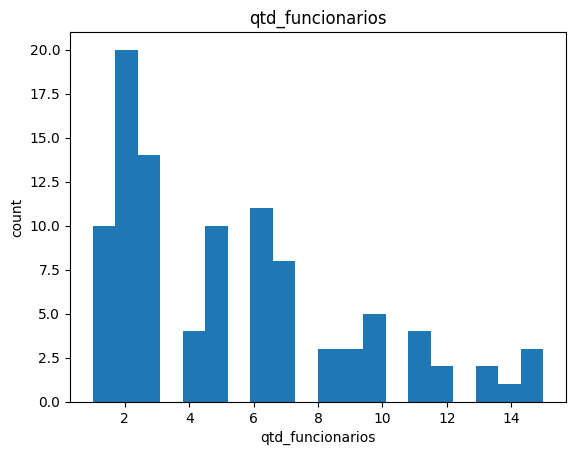

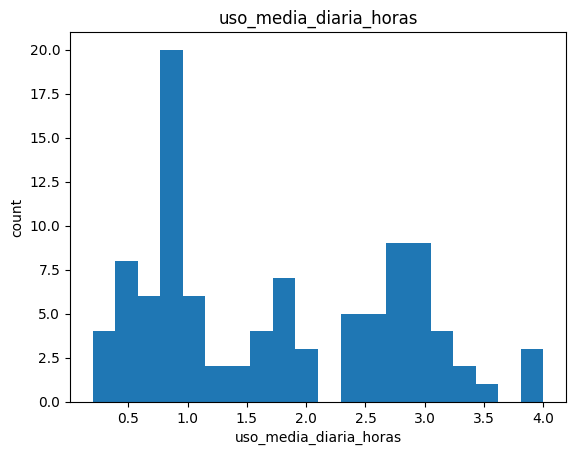

In [47]:
# Histogramas das variáveis numéricas (exclui target)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols = [c for c in num_cols if c != "churn"]

for col in num_cols:
    ax = df[col].plot(kind="hist", bins=20)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    plt.show()

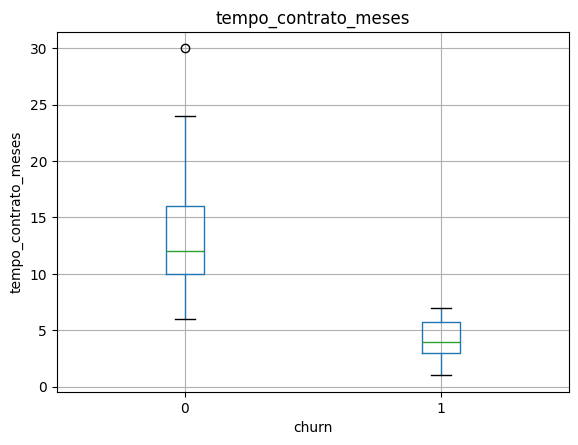

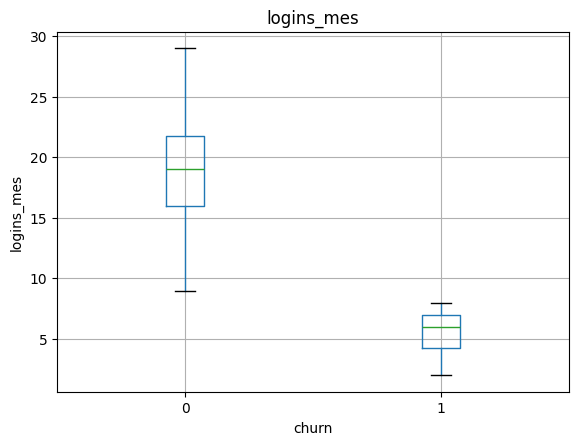

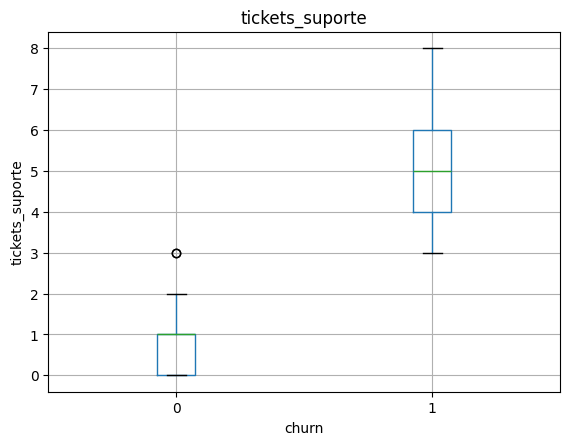

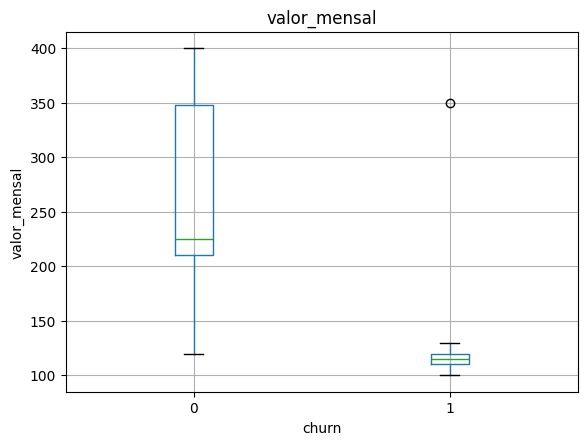

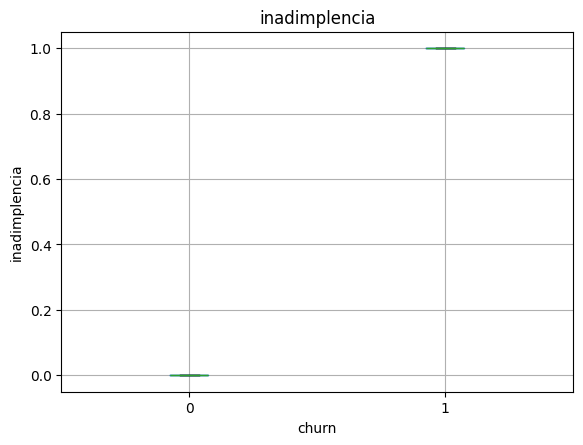

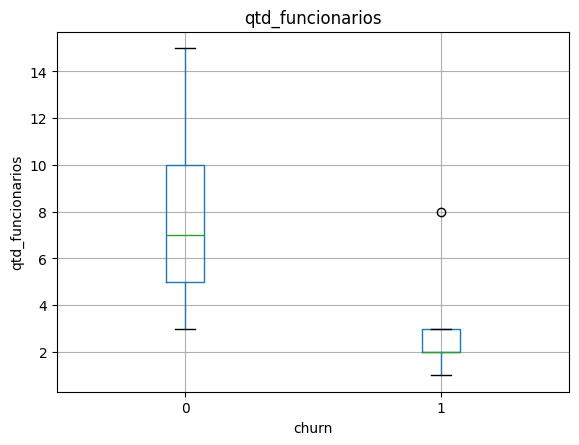

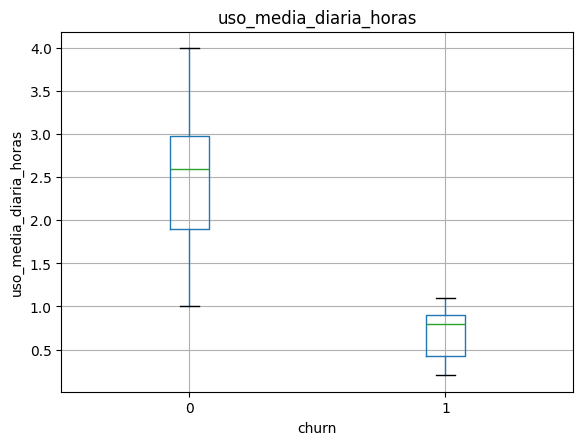

In [48]:
# Comparação churn vs variáveis numéricas (boxplot)
for col in num_cols:
    df.boxplot(column=col, by="churn")
    plt.title(col)
    plt.suptitle("")
    plt.xlabel("churn")
    plt.ylabel(col)
    plt.show()

# Tratar e preparar os dados


In [49]:
from sklearn.model_selection import train_test_split

target = "churn"

X = df.drop(columns=[target]).copy()
y = df[target].copy()

# Remove identificador
if "id_cliente" in X.columns:
    X = X.drop(columns=["id_cliente"])

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.columns.difference(cat_cols).tolist()

# Remoção de colunas numéricas altamente correlacionadas (redundância)
corr = X[num_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop_num = [c for c in upper.columns if any(upper[c] > 0.90)]
to_drop_num

['qtd_funcionarios',
 'tempo_contrato_meses',
 'tickets_suporte',
 'uso_media_diaria_horas',
 'valor_mensal']

In [50]:
if to_drop_num:
    X = X.drop(columns=to_drop_num)
    num_cols = [c for c in num_cols if c not in to_drop_num]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_train.shape, X_test.shape

((70, 4), (30, 4))

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Treinar os modelos


In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    has_xgb = True
except Exception as e:
    has_xgb = False
    xgb_import_error = e

models = {}

models["LogisticRegression"] = LogisticRegression(
    max_iter=2000,
    solver="liblinear",
    class_weight="balanced",
    random_state=42,
)

models["RandomForest"] = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)

if has_xgb:
    models["XGBoost"] = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
    )
else:
    xgb_import_error

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

def evaluate_clf(pipe, X_test, y_test):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

In [55]:
pipes = {}
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pipes[name] = pipe

    metrics = evaluate_clf(pipe, X_test, y_test)
    metrics["model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results).set_index("model").sort_values("roc_auc", ascending=False)
results_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression,1.000000,1.000000,1.0,1.000000,1.0
RandomForest,0.933333,0.866667,1.0,0.928571,1.0


# Avaliar os resultados


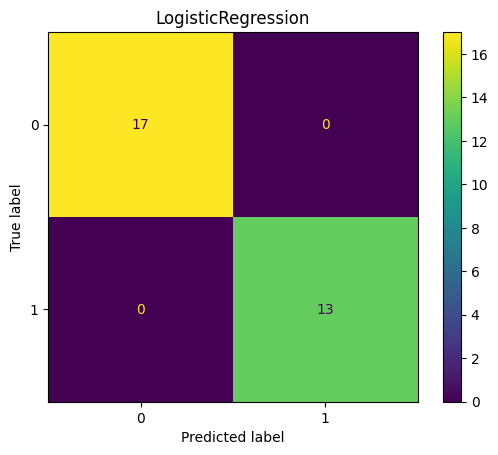

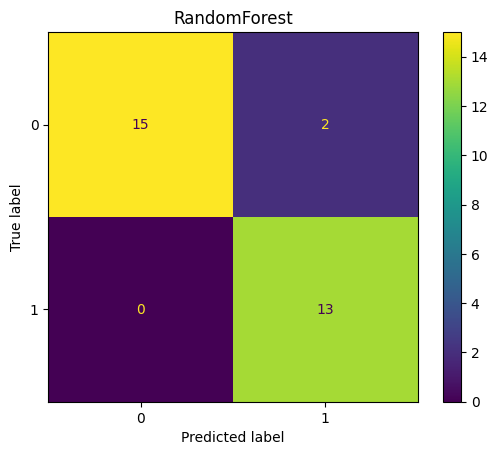

In [56]:
# Matriz de confusão
for name, pipe in pipes.items():
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)
    plt.show()

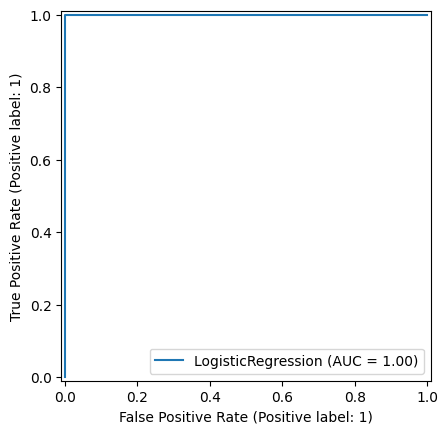

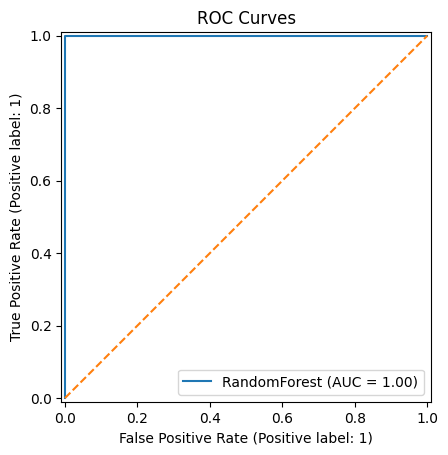

In [57]:
# Curva ROC
for name, pipe in pipes.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves")
plt.show()

# Interpretar e apresentar os resultados


In [58]:
def get_feature_names(preprocess, cat_cols, num_cols):
    ohe = preprocess.named_transformers_["cat"]
    cat_names = list(ohe.get_feature_names_out(cat_cols)) if len(cat_cols) else []
    return list(num_cols) + cat_names

feature_names = get_feature_names(pipes[list(pipes.keys())[0]].named_steps["preprocess"], cat_cols, num_cols)
len(feature_names), feature_names[:10]

(7,
 ['inadimplencia',
  'logins_mes',
  'plano_Intermediário',
  'plano_Premium',
  'regiao_Nordeste',
  'regiao_Sudeste',
  'regiao_Sul'])

In [59]:
# Importância / impacto das variáveis (Top 15)
def top_features_logreg(pipe, feature_names, top_n=15):
    model = pipe.named_steps["model"]
    coef = model.coef_.ravel()
    imp = pd.Series(np.abs(coef), index=feature_names).sort_values(ascending=False).head(top_n)
    return imp

def top_features_tree(pipe, feature_names, top_n=15):
    model = pipe.named_steps["model"]
    imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False).head(top_n)
    return imp

top_tables = {}

if "LogisticRegression" in pipes:
    top_tables["LogisticRegression"] = top_features_logreg(pipes["LogisticRegression"], feature_names)

if "RandomForest" in pipes:
    top_tables["RandomForest"] = top_features_tree(pipes["RandomForest"], feature_names)

if "XGBoost" in pipes:
    top_tables["XGBoost"] = top_features_tree(pipes["XGBoost"], feature_names)

top_tables

{'LogisticRegression': inadimplencia          2.081485
 logins_mes             1.311835
 plano_Intermediário    0.682137
 plano_Premium          0.375433
 regiao_Sudeste         0.354342
 regiao_Nordeste        0.129163
 regiao_Sul             0.017158
 dtype: float64,
 'RandomForest': inadimplencia          0.399161
 logins_mes             0.389649
 plano_Intermediário    0.098079
 plano_Premium          0.051191
 regiao_Sudeste         0.050068
 regiao_Nordeste        0.006073
 regiao_Sul             0.005779
 dtype: float64}

# Conclusões e recomendações

## Variáveis com maior impacto no churn
Use a tabela de importâncias (acima) para identificar as variáveis que mais contribuem para a decisão do modelo. Em churn SaaS, padrões comuns incluem baixo uso do produto, alta demanda de suporte, inadimplência e pouca maturidade de contrato.

## O modelo identifica bem quem vai cancelar?
Acompanhe principalmente recall, precision e ROC-AUC. Para churn, é comum priorizar recall (capturar o máximo de clientes em risco) e controlar precision via threshold e capacidade operacional do time de retenção.

## Recomendações ao time de produto
- Reforçar onboarding e ativação para clientes com baixo uso (uso médio diário e logins/mês baixos).
- Ações proativas para clientes com aumento de tickets de suporte (qualidade do produto e atendimento).
- Políticas e alertas para inadimplência, com fluxos de cobrança e negociação antes do cancelamento.
- Segmentação por plano e região para identificar grupos com churn acima da média e ajustar proposta de valor, preço ou comunicação.
